<a href="https://colab.research.google.com/github/Colosolizer/Carisurg_Week_0_Portfolio/blob/main/Carisurg_week0_task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Carisurg Week 0 Task 3**

Loading and Cleaning Dataset

In [8]:
#Imports and Google Drive Mounting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Google Drive Mount
from google.colab import drive
drive.mount('/content/drive')

#Confirmation Text
print("Your Google Drive has been successfully mounted")

#File path and reading file content
FILE_PATH = '/content/drive/MyDrive/ColabNotebooks/Carisurg_2026/EmergencyTriageDataset_Reduced_Dirty.csv'
df = pd.read_csv(FILE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Your Google Drive has been successfully mounted


In [9]:

#Dataset Cleaning

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total Number of NaNs remaining: {df.isnull().sum().sum()}")
df.head()

Clean dataset: 2205 rows x 11 columns
Total Number of NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


**Histogram : Respiratory Rate Distribution**

The following histogram showcases the breathing pattern of the patients in the dataset revealing any whether or not the patients are mainly experiencing Eupnea , Tachypnea or Bradypnea.



*   Eupnea - Common Breathing Rate
*   Tachypnea - Crtitically Ill Patients suffering from respiratory distress, sepsis, or anxiety. Breathing faster than 20 breaths per minute.

*   Bradypnea- Patients breathing slower than 12 breaths per minute. This might point to patients under heavy sedation, opioid use, or neurological issues.










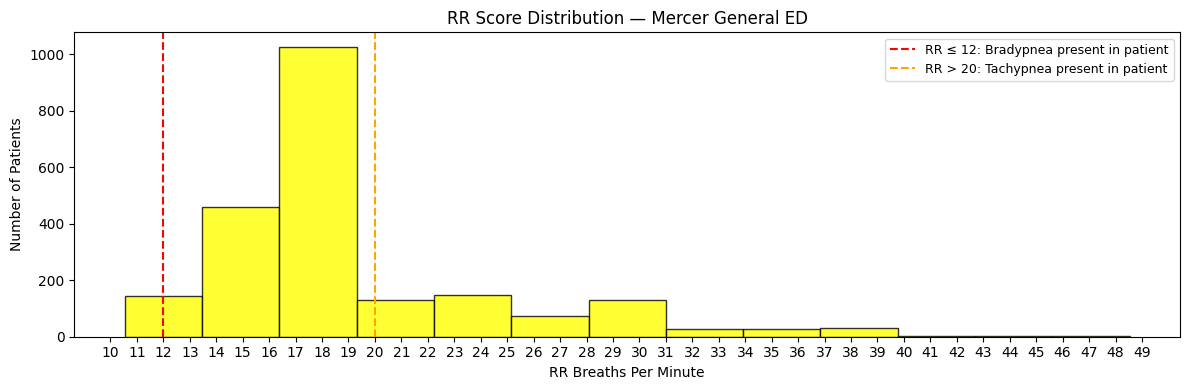

Saved: rr_histogram.png


In [16]:
# Histogram: RR distribution
fig, ax = plt.subplots(figsize=(12, 4))

ax.hist(df['RR'], bins= 13, edgecolor='black',
        color='YELLOW', alpha=0.8, align='left')

# Add a vertical line at the clinical threshold for severe impairment
ax.axvline(x=12, color='red', linestyle='--', linewidth=1.5,
           label='RR ≤ 12: Bradypnea present in patient')
ax.axvline(x=20, color='orange', linestyle='--', linewidth=1.5,
           label='RR > 20: Tachypnea present in patient')

ax.set_title('RR Score Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('RR Breaths Per Minute')
ax.set_ylabel('Number of Patients')
ax.set_xticks(range(10, 50))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('rr_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: rr_histogram.png")

**Scatter Plot : Respiratory Rate (RR) vs Fraction of Inspired Oxygen (FiO2)**

The following scatterplot showcases the breathing pattern of the patients in the dataset plotted against the Fraction of Inspired Oxygen.


Patients with a high FiO2 (lots of oxygen support) and a high RR (breathing very fast) are in severe respiratory distress. This scatter plot helps visually separate stable patients from those on the brink of respiratory failure


Any patient dots that appear in the top-right section of the scatter plot (high FiO2 oxygen support and sitting above the red dashed line) are  critical, high-risk patients.










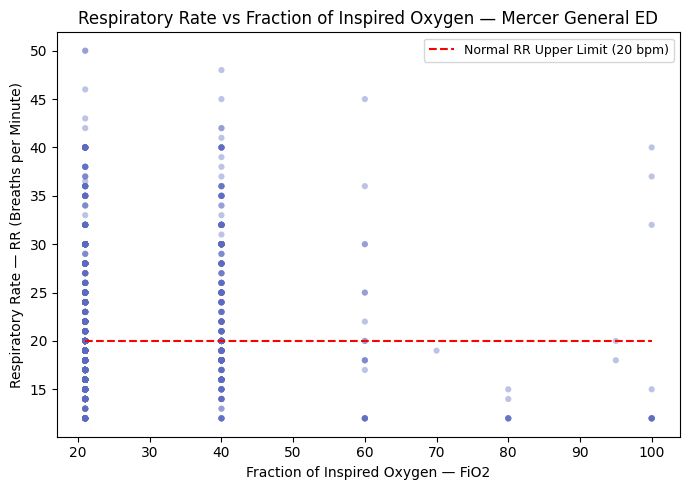

Saved: rr_vs_fio2.png


In [17]:
# Scatter plot: RR vs FiO2
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(df['Fio2'], df['RR'],
                     alpha=0.4, s=20, color='#5C6BC0', edgecolors='none')

# Add a trend reference: Normal upper limit for Respiratory Rate is 20 bpm
fio2_range = np.linspace(df['Fio2'].min(), df['Fio2'].max(), 100)
# np.full creates an array filled entirely with the value 20
ax.plot(fio2_range, np.full_like(fio2_range, 20), color='red', linestyle='--',
        linewidth=1.5, label='Normal RR Upper Limit (20 bpm)')

ax.set_title('Respiratory Rate vs Fraction of Inspired Oxygen — Mercer General ED', fontsize=12)
ax.set_xlabel('Fraction of Inspired Oxygen — FiO2')
ax.set_ylabel('Respiratory Rate — RR (Breaths per Minute)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('rr_vs_fio2.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: rr_vs_fio2.png")